# OpenScope Predictive Processing: random mesoscope NWB → image + stimulus-triggered calcium response

This Colab-ready notebook works with the **OpenScope Predictive Processing Community – Mesoscope** Dandiset (**DANDI:001768**).

It will:

1. Query DANDI for mesoscope NWB assets.
2. Select **one NWB at random** (set `RANDOM_SEED = None` for a new choice each run).
3. Stream the NWB from DANDI instead of downloading the whole file.
4. Find an imaging plane and plot an available projection/summary image.
5. Find a ΔF/F calcium trace and a stimulus `TimeIntervals` table.
6. Plot a stimulus-triggered population response (calcium PSTH / peri-stimulus average).

The notebook intentionally inspects the NWB rather than hard-coding every object name because object names can vary between sessions.

**Project references:**  
- OpenScope Predictive Processing data release: https://allenneuraldynamics.github.io/openscope_p3_data_release_paper/  
- DANDI: https://dandiarchive.org/dandiset/001768  
- Project: https://allenneuraldynamics.github.io/openscope-community-predictive-processing/

> Note: For calcium imaging, “PSTH” is used here in the broad peri-stimulus sense. The plotted quantity is the mean ΔF/F aligned to stimulus onset, not a spike-count histogram.

In [ ]:
# Colab setup
!pip -q install "dandi>=0.67" "pynwb>=3.0" "h5py>=3.10" "remfile>=0.1.13" matplotlib pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.6/409.6 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.0/122.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.6/366.6 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py, remfile

from dandi.dandiapi import DandiAPIClient
from pynwb import NWBHDF5IO

DANDISET_ID = "001768"
DANDISET_VERSION = "draft"

# Change to None to get a different random file on every run.
RANDOM_SEED = 20260905
rng = random.Random(RANDOM_SEED)

client = DandiAPIClient()
client.__enter__()
dandiset = client.get_dandiset(DANDISET_ID, version_id=DANDISET_VERSION)

assets = [a for a in dandiset.get_assets() if a.path.lower().endswith(".nwb")]
print(f"Found {len(assets)} NWB assets in DANDI:{DANDISET_ID}")

if not assets:
    raise RuntimeError("No .nwb assets found. Check whether the Dandiset/version has changed.")

asset = rng.choice(assets)
print("Randomly selected asset:")
print(asset.path)
print("Asset identifier:", asset.identifier)

Found 86 NWB assets in DANDI:001768
Randomly selected asset:
sub-842971/sub-842971_ses-multiplane-ophys-842971-2026-05-08-09-32-15_ophys.nwb
Asset identifier: 2c63a437-a60f-4be1-b9de-54f5149cb280


In [ ]:
# Stream the selected NWB over HTTP range requests.
# This avoids downloading the complete file.

url = asset.get_content_url(follow_redirects=1, strip_query=True)
remote_file = remfile.File(url)
h5_file = h5py.File(remote_file, "r")
io = NWBHDF5IO(file=h5_file, mode="r", load_namespaces=True)
nwb = io.read()

print("Session:", nwb.session_description)
print("Identifier:", nwb.identifier)
print("Session start:", nwb.session_start_time)
print("Processing modules:", list(nwb.processing.keys()))
print("Interval tables:", list(nwb.intervals.keys()))

/usr/local/lib/python3.13/dist-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for TimestampVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/usr/local/lib/python3.13/dist-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for DurationVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/usr/local/lib/python3.13/dist-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for MeaningsTable than the existing definition from table.yaml. Defaulting to the existing specif

Session: A Unknown Project  experiment performed using OPTICAL_SESSION4_SENSORYMOTOR behavior. Experiment includes Planar optical physiology, Behavior videos, Behavior modalities.
Identifier: 803728dd-5eb3-412e-9624-a95079d0ff60
Session start: 2026-05-08 09:32:15.464865-07:00
Processing modules: ['VISl_4', 'VISl_5', 'VISl_6', 'VISl_7', 'VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'eye_tracking', 'running', 'stimulus']
Interval tables: ['Control block 1_presentations', 'Control block 2_presentations', 'Control block 3_presentations', 'Control block 4_presentations', 'RF mapping_presentations', 'Sensory-motor mismatch block_presentations', 'Zebra_presentations', 'spontaneous_presentations']


## 1. Plot a calcium-imaging field-of-view image

Mesoscope NWBs contain processing modules for imaging planes. We search those modules for an `Images` interface and display the first useful 2-D projection/summary image we find.

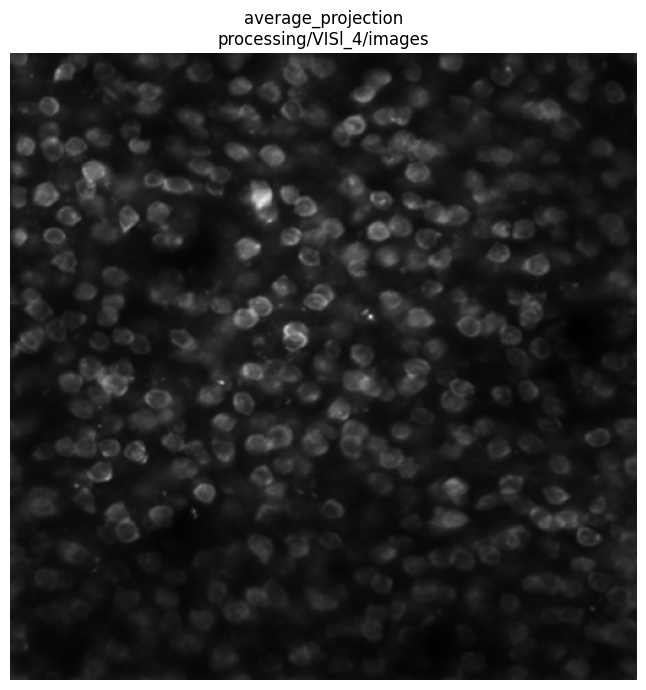

Image shape: (512, 512)


In [ ]:
def find_projection_images(nwb):
    found = []
    for module_name, module in nwb.processing.items():
        for iface_name, iface in module.data_interfaces.items():
            # Images containers normally expose an .images mapping
            if hasattr(iface, "images"):
                try:
                    for image_name, img in iface.images.items():
                        arr = np.asarray(img.data)
                        if arr.ndim == 2:
                            found.append((module_name, iface_name, image_name, arr))
                except Exception:
                    pass
    return found

projection_images = find_projection_images(nwb)

if not projection_images:
    raise RuntimeError(
        "No 2-D projection image was found automatically in this NWB. "
        "Inspect nwb.processing to adapt the image lookup for this asset."
    )

module_name, iface_name, image_name, image = projection_images[0]

plt.figure(figsize=(7, 7))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title(f"{image_name}\nprocessing/{module_name}/{iface_name}")
plt.tight_layout()
plt.show()

print("Image shape:", image.shape)

## 2. Locate ΔF/F and stimulus timing

The code below searches the selected session for a calcium ΔF/F time series and chooses a stimulus interval table containing onset times. It prints what it selected so the analysis remains auditable.

In [ ]:
def find_dff_series(nwb):
    candidates = []
    for module_name, module in nwb.processing.items():
        for iface_name, iface in module.data_interfaces.items():
            names = [
                str(module_name).lower(),
                str(iface_name).lower(),
                iface.__class__.__name__.lower(),
            ]
            # Search one level down for RoiResponseSeries-like objects
            containers = []
            if hasattr(iface, "roi_response_series"):
                try:
                    containers.extend(iface.roi_response_series.values())
                except Exception:
                    pass
            if hasattr(iface, "time_series"):
                try:
                    containers.extend(iface.time_series.values())
                except Exception:
                    pass
            # Some project files expose a named time series directly.
            if hasattr(iface, "data") and ("dff" in " ".join(names) or "df/f" in " ".join(names)):
                containers.append(iface)

            for ts in containers:
                label = " ".join(names + [str(getattr(ts, "name", "")).lower()])
                if any(k in label for k in ["dff", "df/f", "dfoverf"]):
                    candidates.append((module_name, iface_name, ts))
    return candidates

dff_candidates = find_dff_series(nwb)
print("ΔF/F candidates:", [(m, i, getattr(ts, "name", "")) for m, i, ts in dff_candidates[:20]])

if not dff_candidates:
    raise RuntimeError("Could not automatically locate a ΔF/F time series in this asset.")

dff_module, dff_iface, dff_ts = dff_candidates[0]
print("\nUsing ΔF/F:", dff_module, "/", dff_iface, "/", dff_ts.name)

# Choose a stimulus-like interval table with start_time.
interval_candidates = []
for name, table in nwb.intervals.items():
    cols = list(table.colnames)
    score = sum(k in name.lower() for k in ["stim", "trial", "grating", "oddball", "mismatch"])
    if "start_time" in cols:
        interval_candidates.append((score, name, table))

if not interval_candidates:
    raise RuntimeError("No interval table with start_time was found.")

interval_candidates.sort(key=lambda x: x[0], reverse=True)
_, stim_table_name, stim_table = interval_candidates[0]
stim_df = stim_table.to_dataframe()

print("Using stimulus table:", stim_table_name)
print("Columns:", list(stim_df.columns))
display(stim_df.head())

ΔF/F candidates: [('VISl_4', 'dff_timeseries', 'dff_timeseries'), ('VISl_5', 'dff_timeseries', 'dff_timeseries'), ('VISl_6', 'dff_timeseries', 'dff_timeseries'), ('VISl_7', 'dff_timeseries', 'dff_timeseries'), ('VISp_0', 'dff_timeseries', 'dff_timeseries'), ('VISp_1', 'dff_timeseries', 'dff_timeseries'), ('VISp_2', 'dff_timeseries', 'dff_timeseries'), ('VISp_3', 'dff_timeseries', 'dff_timeseries')]

Using ΔF/F: VISl_4 / dff_timeseries / dff_timeseries
Using stimulus table: Sensory-motor mismatch block_presentations
Columns: ['start_time', 'stop_time', 'stim_name', 'stim_type', 'stim_block', 'Orientation', 'SpatialFrequency', 'TemporalFrequency', 'contrast', 'phase', 'DiameterX', 'DiameterY', 'X', 'Y', 'Duration', 'Delay', 'BlockNumber', 'BlockLabel', 'TrialNumber', 'SequenceNumber', 'TrialInSequence', 'TrialType', 'BlockType', 'stim_index', 'timeseries']


,start_time,stop_time,stim_name,stim_type,stim_block,Orientation,SpatialFrequency,TemporalFrequency,contrast,phase,...,Delay,BlockNumber,BlockLabel,TrialNumber,SequenceNumber,TrialInSequence,TrialType,BlockType,stim_index,timeseries
id,,,,,,,,,,,,,,,,,,,,,
0,433.01355,433.04692,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,1.7374672889709473,...,0.0,2.0,Sensory-motor mismatch block,545.0,0.0,0.0,standard,motor_oddball,0.0,"[(544, 1, timestamps pynwb.base.TimeSeries at ..."
1,433.04692,433.08032,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,1.7374672889709473,...,0.0,2.0,Sensory-motor mismatch block,546.0,0.0,0.0,standard,motor_oddball,0.0,"[(545, 1, timestamps pynwb.base.TimeSeries at ..."
2,433.08032,433.11374,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,1.7374672889709473,...,0.0,2.0,Sensory-motor mismatch block,547.0,0.0,0.0,standard,motor_oddball,0.0,"[(546, 1, timestamps pynwb.base.TimeSeries at ..."
3,433.11374,433.14711,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,1.7374672889709473,...,0.0,2.0,Sensory-motor mismatch block,548.0,0.0,0.0,standard,motor_oddball,0.0,"[(547, 1, timestamps pynwb.base.TimeSeries at ..."
4,433.14711,433.18041,Sensory-motor mismatch block,None or Blank,1.0,0.0,0.04,0.0,1.0,1.7374672889709473,...,0.0,2.0,Sensory-motor mismatch block,549.0,0.0,0.0,standard,motor_oddball,0.0,"[(548, 1, timestamps pynwb.base.TimeSeries at ..."


In [ ]:
# Convert the ΔF/F series to a time x ROI representation.

data = np.asarray(dff_ts.data)

if getattr(dff_ts, "timestamps", None) is not None:
    timestamps = np.asarray(dff_ts.timestamps)
else:
    rate = getattr(dff_ts, "rate", None)
    starting_time = getattr(dff_ts, "starting_time", 0.0)
    if rate is None:
        raise RuntimeError("The selected ΔF/F series has neither timestamps nor a sampling rate.")
    timestamps = starting_time + np.arange(data.shape[0]) / rate

# NWB RoiResponseSeries is conventionally time x ROI.
# If dimensions appear reversed, transpose using timestamp length as the guide.
if data.shape[0] != len(timestamps) and data.ndim == 2 and data.shape[1] == len(timestamps):
    data = data.T

if data.shape[0] != len(timestamps):
    raise RuntimeError(f"Could not reconcile data shape {data.shape} with {len(timestamps)} timestamps.")

print("ΔF/F shape (time x ROI):", data.shape)
print("Time span:", float(timestamps[0]), "to", float(timestamps[-1]), "s")

ΔF/F shape (time x ROI): (41005, 356)
Time span: 52.55462 to 4378.19656 s


## 3. Stimulus-triggered calcium response (PSTH)

For a robust first-look figure, we average ΔF/F across ROIs, align that population signal to each stimulus onset, baseline-correct each trial using −1 to 0 s, and then average across stimuli.

This is intentionally a **general stimulus-triggered response**. Once you identify the paradigm/columns in the selected session, you can split trials into expected vs. mismatch conditions.

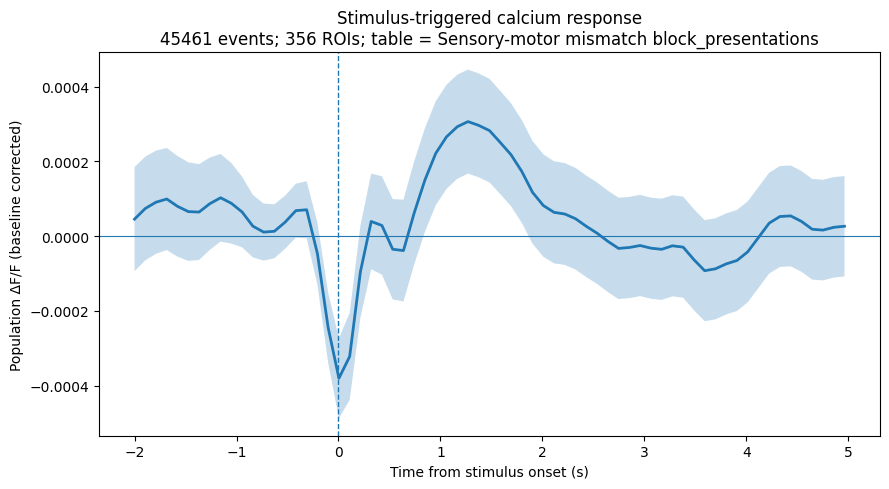

In [ ]:
# Population calcium trace. nanmean tolerates occasional missing ROI samples.
population_dff = np.nanmean(data, axis=1)

# Stimulus onsets inside the calcium recording.
onsets = pd.to_numeric(stim_df["start_time"], errors="coerce").dropna().to_numpy(float)
onsets = onsets[(onsets > timestamps[0]) & (onsets < timestamps[-1])]

pre, post = 2.0, 5.0
dt = float(np.nanmedian(np.diff(timestamps)))
grid = np.arange(-pre, post + dt/2, dt)

aligned = []
for onset in onsets:
    if onset + grid[0] < timestamps[0] or onset + grid[-1] > timestamps[-1]:
        continue
    trial = np.interp(onset + grid, timestamps, population_dff)
    baseline = np.nanmean(trial[(grid >= -1.0) & (grid < 0)])
    aligned.append(trial - baseline)

aligned = np.asarray(aligned)

if len(aligned) == 0:
    raise RuntimeError("No complete stimulus-aligned windows were available.")

mean_resp = np.nanmean(aligned, axis=0)
sem_resp = np.nanstd(aligned, axis=0, ddof=1) / np.sqrt(aligned.shape[0])

plt.figure(figsize=(9, 5))
plt.plot(grid, mean_resp, lw=2)
plt.fill_between(grid, mean_resp-sem_resp, mean_resp+sem_resp, alpha=0.25)
plt.axvline(0, ls="--", lw=1)
plt.axhline(0, lw=0.8)
plt.xlabel("Time from stimulus onset (s)")
plt.ylabel("Population ΔF/F (baseline corrected)")
plt.title(
    f"Stimulus-triggered calcium response\n"
    f"{aligned.shape[0]} events; {data.shape[1]} ROIs; table = {stim_table_name}"
)
plt.tight_layout()
plt.show()

## Optional: inspect stimulus conditions for the next analysis

The scientifically interesting next step is to use the stimulus-table columns to separate **expected/control** and **mismatch/deviant** trials, then compute condition-specific peri-stimulus responses and mismatch indices.

In [ ]:
print("Stimulus table:", stim_table_name)
print("Available columns:")
for c in stim_df.columns:
    print(" •", c)

# Show unique values for manageable categorical columns.
for c in stim_df.columns:
    try:
        vals = stim_df[c].dropna().unique()
        if 1 < len(vals) <= 20:
            print(f"\n{c}: {vals}")
    except Exception:
        pass

Stimulus table: Sensory-motor mismatch block_presentations
Available columns:
 • start_time
 • stop_time
 • stim_name
 • stim_type
 • stim_block
 • Orientation
 • SpatialFrequency
 • TemporalFrequency
 • contrast
 • phase
 • DiameterX
 • DiameterY
 • X
 • Y
 • Duration
 • Delay
 • BlockNumber
 • BlockLabel
 • TrialNumber
 • SequenceNumber
 • TrialInSequence
 • TrialType
 • BlockType
 • stim_index
 • timeseries

Orientation: ['0.0' '1.5707963267948966' '0.7853981633974483']

TemporalFrequency: ['0.0' '2.0']

contrast: ['1.0' '0.0']

Duration: ['0.0333333333333333' '0.343']

TrialType: ['standard' 'motor_orientation_90' 'motor_orientation_45' 'motor_omission'
 'motor_halt']


In [ ]:
# Cleanly close the remote file when finished.
io.close()
h5_file.close()
remote_file.close()
client.__exit__(None, None, None)
print("Closed DANDI/NWB connections.")

Closed DANDI/NWB connections.
